In [1]:
import os
import json
import gzip
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py

from karhu.utils_input import *
from karhu.utils_helena import load_from_helena
from karhu.common import pol2cart

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Load data

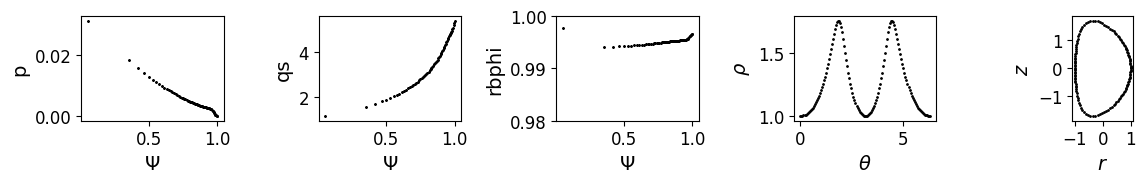

In [2]:
"""
The data directory in the example folder contains the HELENA files needed to construct the model input.
You can replace this with your own HELENA equilibrium files. The model predicts the maximum growth rate of
the given equilibrium.
The reference values are the mode number (Ntor) specific growth rates calculated by MISHKA for the same equilibrium.
"""
rundir = "./data/jet_2H/"
y_true = [0.0, 0.0, 0.0, 0.0, np.sqrt(0.5405E-03), np.sqrt(0.1058E-02), 0.8027E-03, 0.0]
x_true = [3, 5, 7, 10, 15, 20, 30, 50,]


# Dummy config
model_config = {
    "karhu_psin_axis": np.linspace(1e-5, 1.0, 64)**(1/4),
    "karhu_theta_axis": np.linspace(1e-5, 2*np.pi, 128)}

with gzip.open(os.path.join(rundir, 'fort.12.gz'), 'rb') as f_in:
    with open(os.path.join(rundir, 'fort.12'), 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

x_helena = load_from_helena(rundir,
    karhu_psin_axis=model_config["karhu_psin_axis"],
    karhu_theta_axis=model_config["karhu_theta_axis"])

# Plot the equilibrium profiles
fig_x, axs = plt.subplots(1, 5, figsize=(12, 2))
for i, label in enumerate(['p', 'qs', 'rbphi']):
    axs[i].plot(model_config["karhu_psin_axis"], x_helena[i].flatten(), ".", c="black", markersize=2, fillstyle="top")
    axs[i].set_xlabel(r"$\Psi$")
    axs[i].set_ylabel(label)
axs[3].plot(model_config["karhu_theta_axis"], x_helena[3].flatten(), ".", c="black", markersize=2, fillstyle="full")
axs[3].set_xlabel(r"$\theta$")
axs[3].set_ylabel(r"$\rho$")
r, z = pol2cart(x_helena[3].flatten().numpy(), model_config["karhu_theta_axis"])
axs[4].plot(r, z, ".", c="black", markersize=2, fillstyle="full")
axs[4].set_xlabel(r"$r$")
axs[4].set_ylabel(r"$z$")
axs[4].set_aspect("equal")

axs[2].set_ylim(0.98, 1.0)
plt.tight_layout()
plt.savefig("equilibrium.png", transparent=True, bbox_inches="tight")

plt.show()


## Ensemble inference

In [5]:
ensemble_dir = "../model_ensemble/jet_diii-d"
models, model_config = load_ensemble_model(ensemble_dir)
scaling_params = model_config["scaling_params"]
x = scale_model_input(x_helena, scaling_params)

ensemble_preds = []

for model in models:
    with torch.no_grad():        
        y_pred_norm = model(*x)
    y_pred = scale_model_output(y_pred_norm, scaling_params)
    ensemble_preds.append(y_pred)

ensemble_preds = np.stack(ensemble_preds, axis=0)
y_pred_mean = ensemble_preds.mean(axis=0)
y_pred_std = ensemble_preds.std(axis=0)
print(f"Predicted mean growth rate: {y_pred_mean:.4f} with std: {y_pred_std:.4f}")


Predicted mean growth rate: 0.0589 with std: 0.0073


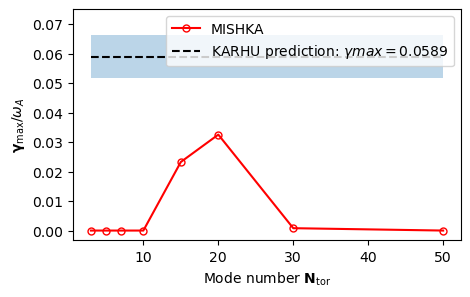

In [6]:

fig_prediction, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.plot(x_true, y_true, ".-", c="red", markersize=10, fillstyle="none", label="MISHKA",)
plt.hlines(
    y=y_pred_mean, xmin=3, xmax=50,
    colors='black', linestyles='dashed',
    label=f'KARHU prediction: $\gamma max = ${y_pred_mean:.4f}')
plt.fill_between(
    x_true,
    y_pred_mean - y_pred_std,
    y_pred_mean + y_pred_std,
    alpha=0.3
)
plt.xlabel(r"Mode number $\mathbf{N_{\text{tor}}}$")
plt.ylabel(r"$\mathbf{\gamma_{\text{max}}}/\omega_A$")
plt.ylim(None, 0.075)
plt.legend()
plt.show()

## Single model inference

In [5]:
# from karhu.gntor import load_model, load_ensemble_model, get_ensemble_prediction

# # Load model
# model_dir = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/models/model_20260608_103645"
# model, model_config = load_model(model_dir)
# scaling_params = model_config["scaling_params"]

from karhu.gntor_cvae import load_model

model_dir = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/models/model_20260612_130000_cvaea"
model, model_config = load_model(model_dir)
scaling_params = model_config["scaling_params"]


[ 0.07542589  0.08327763  0.08223019  0.07015749  0.04134202  0.02000422
 -0.00024266  0.00272458]
[0.07542589 0.08327763 0.08223019 0.07015749 0.04134202 0.02000422
 0.         0.00272458]


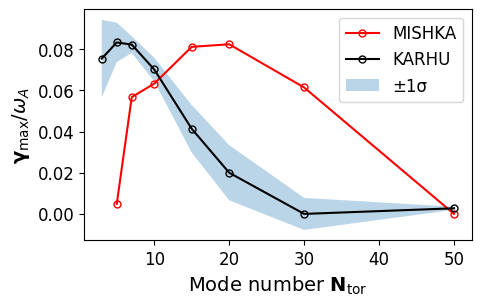

In [10]:
from karhu.gntor_cvae import predict as predict_cvae
x_pred = np.array([3,5,7,10,15,20,30,50])
x = scale_model_input(x_helena, scaling_params)
x_in = torch.cat(
    [
        x[0].flatten().flatten(),
        x[1].flatten().flatten(),
        x[2].flatten().flatten(),
        x[3].flatten().flatten(),
        x[4],
        x[5]
    ], dim=0).unsqueeze(dim=0)

y_mean, y_std = predict_cvae(model, x_in, n_samples=50, device="cpu")
y_mean = y_mean.cpu().numpy().flatten()
y_std = y_std.cpu().numpy().flatten()
y_pred = y_mean

# y_pred = model(*x)
y_pred = descale_minmax(
    y_pred,
    scaling_params["growthrate"][0],
    scaling_params["growthrate"][1],
)
y_std = descale_minmax(
    y_std,
    scaling_params["growthrate"][0],
    scaling_params["growthrate"][1],
)
print(y_pred)
y_pred = np.maximum(0.0, y_pred)
print(y_pred)

# x_c = scale_model_input(x_helena, c_scaling_params)
# y_pred_c = c_model(*x_c)
# y_pred_c = descale_minmax(
#     y_pred_c,
#     c_scaling_params["growthrate"][0],
#     c_scaling_params["growthrate"][1],
# )
# y_pred_c = torch.sigmoid(y_pred_c).detach().numpy().flatten()
# print(y_pred_c)


fig_prediction, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.plot(x_true, y_true, ".-", c="red", markersize=10, fillstyle="none", label="MISHKA",)
plt.plot(x_pred, y_pred, ".-", c="black", markersize=10, fillstyle="none", label="KARHU",)  # np.arange(3,50,1)
plt.fill_between(
    x_pred,
    y_pred - y_std,
    y_pred + y_std,
    alpha=0.3,
    label="±1σ",
)
# plt.hlines(y=y_pred, xmin=3, xmax=50, colors='black', linestyles='dashed', label=f'KARHU prediction: $\gamma max = ${y_pred:.4f}')
plt.xlabel(r"Mode number $\mathbf{N_{\text{tor}}}$")
plt.ylabel(r"$\mathbf{\gamma_{\text{max}}}/\omega_A$")
plt.legend()
plt.show()


In [10]:
import h5py

h5_path_interp = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/db/jet_1H/interpolated64.h5"
with h5py.File(h5_path_interp, "r") as f:
    qs = f["profiles/qs"][:]
    p0 = f["profiles/p0"][:]
    rbphi = f["profiles/rbphi"][:]
    boundary = f["profiles/boundary_polar"][:]
    rmag = f["scalars/rmag"][:]
    bmag = f["scalars/bmag"][:]
    gamma_max = f["scalars/max_gr_mishka"][:]
    karhu_psin_axis = f["karhu/psin_axis"][:]
    karhu_theta_axis = f["karhu/theta_axis"][:]
    mishka_ntor = f["growthrates_mishka"]["ntor"][:]
    mishka_gamma2 = f["growthrates_mishka"]["gamma2"][:]
    mishka_iterations = f["growthrates_mishka"]["iterations"][:]


/scratch/project_2009007/data_JET_2H/test_cases/tria_options/7a95d5c2-3a9c-4ff4-bc88-aef603bb7ca1 0.18748167157173157
[0.1185327  0.12087183 0.13315405 0.11126545 0.09723682 0.062522
 0.        ]


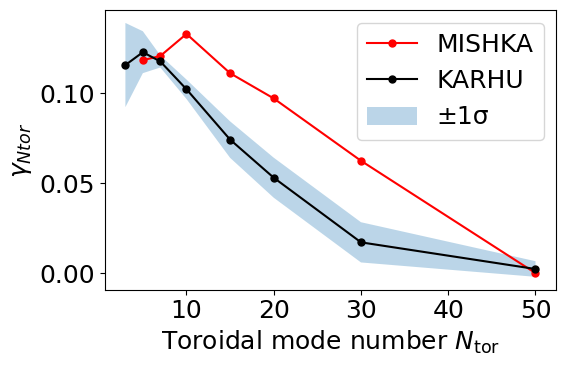

In [20]:
europed_scans_path = "/scratch/project_2009007/data_JET_2H/test_cases/tria_options"
# europed_scans_path = "/scratch/project_2009007/data_JET_2H/1d_scan/simulations"
# europed_scans_path = "/scratch/project_2009007/data_JET_pdb/beta_core_slope/rundir_hm/data"
# europed_scans_path = "/scratch/project_2009007/data_JET_europeddb/enchanted_rundir"

SMALL_SIZE = 8
MEDIUM_SIZE = 18
BIGGER_SIZE = 18
BIG_SIZE = 28

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
# plt.rc('axes', ticksize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels

x_pred = [3, 5, 7, 10, 15, 20, 30, 50,]

for scan_path in sorted([f.path for f in os.scandir(europed_scans_path) if f.is_dir()])[3:4]:
    try:
        
        namelist_path = os.path.join(scan_path, "fort.10")
        namelist = f90nml.read(namelist_path)
        tria = namelist['shape']['tria']
        print(scan_path, tria)
        
        x_helena = load_from_helena(scan_path,
            karhu_psin_axis=model_config["karhu_psin_axis"],
            karhu_theta_axis=model_config["karhu_theta_axis"])
        
        ntor_growthrates = np.load(os.path.join(scan_path, "growthrates_mishka.npy"))
        x_true = ntor_growthrates[:,0]
        y_true = ntor_growthrates[:,1]
        i_true = ntor_growthrates[:,3]
        sort_idx = np.argsort(x_true)
        x_true = x_true[sort_idx]
        y_true = y_true[sort_idx]
        i_true = i_true[sort_idx]
        y_true = [np.maximum(float(yi), 0.0) for yi in y_true]
        y_true = np.sqrt(np.array(y_true))
        print(y_true)
        
            
        x = scale_model_input(x_helena, scaling_params)
        
        x_in = torch.cat(
            [
                x[0].flatten().flatten(),
                x[1].flatten().flatten(),
                x[2].flatten().flatten(),
                x[3].flatten().flatten(),
                x[4],
                x[5]
            ], dim=0).unsqueeze(dim=0)

        y_mean, y_std = predict_cvae(model, x_in, n_samples=500, device="cpu")
        y_mean = y_mean.cpu().numpy().flatten()
        y_std = y_std.cpu().numpy().flatten()
        y_pred = y_mean

        y_pred = descale_minmax(
            y_pred,
            scaling_params["growthrate"][0],
            scaling_params["growthrate"][1],
        )
        y_std = descale_minmax(
            y_std,
            scaling_params["growthrate"][0],
            scaling_params["growthrate"][1],
        )
        y_pred = np.maximum(0.0, y_pred)

        # x_c = scale_model_input(x_helena, c_scaling_params)
        # y_pred_c = c_model(*x_c)
        # y_pred_c = descale_minmax(
        #     y_pred_c,
        #     c_scaling_params["growthrate"][0],
        #     c_scaling_params["growthrate"][1],
        # )
        # y_pred_c = torch.sigmoid(y_pred_c).detach().numpy().flatten()
        # print(y_pred_c)

        
        fig_prediction, ax1 = plt.subplots(1, 1, figsize=(6, 4))
        ax1.plot(x_true, y_true, ".-", c="red",
            markersize=10,
            # fillstyle="none",
            label="MISHKA",)
        ax1.plot(x_pred, y_pred, ".-", c="black",
            markersize=10, 
            # fillstyle="none", 
            label="KARHU",)
        ax1.fill_between(
            x_pred,
            y_pred - y_std,
            y_pred + y_std,
            alpha=0.3,
            label="±1σ",
        )
        # for xi, yi, ii in zip(x_true, y_true, i_true):
        #     ax1.annotate(
        #         f"{int(ii)}",
        #         (xi, yi),
        #         c='red',
        #         xytext=(5, 5),
        #         textcoords="offset points",
        #         fontsize=8,
        #         bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"),
        #     )
        
        # ax2 = ax1.twinx()
        # ax2.plot(x_pred, y_pred_c)

        ax1.set_xlabel(r"Toroidal mode number ${N_{\text{tor}}}$")
        ax1.set_ylabel(r"$\gamma_{Ntor}$")
        # ax1.set_xlabel(r"Toroidal mode number $\mathbf{N_{\text{tor}}}$")
        # ax1.set_ylabel(r"$\mathbf{\gamma_{\text{max}}}/\omega_A$")
        ax1.set_ylim(None, np.max([1.1*np.max(y_true), 1.1*np.max(y_pred), 0.05]))
        # ax2.set_ylim(-0.05, 1.05)

        fig_prediction.tight_layout()
        ax1.legend()
        

        fig_prediction.patch.set_facecolor("none")  # transparent figure
        ax1.set_facecolor("white")        # white plotting region

        plt.savefig("test_inf.svg", bbox_inches="tight")

        plt.show()
    except Exception as e:
        print(e)



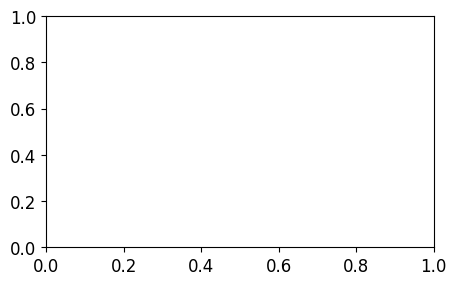

In [10]:
# europed_scans_path = "/scratch/project_2009007/data_JET_europed/84541_2025"
x_values = [3,5,7,10,15,20,30,50]
x_values = [3,5,7,10,15,20]
x_values = []

fig_prediction, ax = plt.subplots(1, 1, figsize=(5, 3))
y_true_max = []
y_pred_max = []
for scan_path in sorted([f.path for f in os.scandir(europed_scans_path) if f.is_dir()]):
    try:
        namelist_path = os.path.join(scan_path, "fort.10")
        namelist = f90nml.read(namelist_path)
        tria = namelist['shape']['tria']
        tria = namelist['phys']['ete']
        x_values.append(tria)
        
        
        ntor_growthrates = np.load(os.path.join(scan_path, "growthrates_mishka.npy"))
        x_true = ntor_growthrates[:,0]
        y_true = ntor_growthrates[:,1]
        sort_idx = np.argsort(x_true)
        x_true = x_true[sort_idx]
        y_true = y_true[sort_idx]
        y_true = [np.maximum(float(yi), 0.0) for yi in y_true]
        y_true = np.sqrt(np.array(y_true))

        x_helena = load_from_helena(scan_path,
            karhu_psin_axis=model_config["karhu_psin_axis"],
            karhu_theta_axis=model_config["karhu_theta_axis"])
        
        x = scale_model_input(x_helena, scaling_params)
        x_in = torch.cat(
            [
                x[0].flatten().flatten(),
                x[1].flatten().flatten(),
                x[2].flatten().flatten(),
                x[3].flatten().flatten(),
                x[4],
                x[5]
            ], dim=0).unsqueeze(dim=0)

        y_mean, y_std = predict_cvae(model, x_in, n_samples=50, device="cpu")
        y_mean = y_mean.cpu().numpy().flatten()
        y_std = y_std.cpu().numpy().flatten()
        y_pred = y_mean

        y_pred = descale_minmax(
            y_pred,
            scaling_params["growthrate"][0],
            scaling_params["growthrate"][1],
        )
        y_std = descale_minmax(
            y_std,
            scaling_params["growthrate"][0],
            scaling_params["growthrate"][1],
        )
        y_pred = np.maximum(0.0, y_pred)

        y_pred_max.append(np.max(y_pred))
        y_true_max.append(np.max(y_true))
    except Exception as e:
        print(e)
        pass

# plt.plot(x_values, y_true_max, ".", c="red", markersize=10, fillstyle="none", label="MISHKA",)
# plt.plot(x_values, y_pred_max, ".", c="black", markersize=10, fillstyle="none", label="KARHU",)
# # plt.hlines(y=y_pred, xmin=3, xmax=50, colors='black', linestyles='dashed', label=f'KARHU prediction: $\gamma max = ${y_pred:.4f}')
# plt.xlabel(r"Mode number $\mathbf{N_{\text{tor}}}$")
# plt.ylabel(r"$\mathbf{\gamma_{\text{max}}}/\omega_A$")
# # plt.ylim(None, np.max([1.1*np.max(y_true), 1.1*np.max(y_pred), 0.05]))
# plt.legend()
# plt.show()


30 30


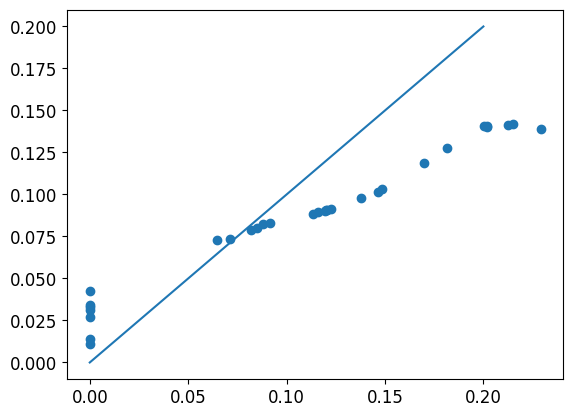

In [11]:
print(len(y_true_max), len(y_pred_max))

plt.scatter(y_true_max, y_pred_max)
plt.plot([0.0,0.2], [0.0,0.2])


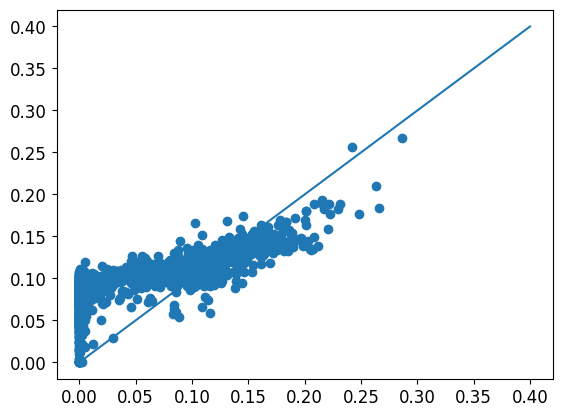

In [ ]:
plt.scatter(y_true_max, y_pred_max)
plt.plot([0.0,0.4], [0.0,0.4])

In [12]:
mishka_ntor.shape, mishka_gamma2.shape, mishka_iterations.shape

((6301,), (6301,), (6301,))

In [13]:
def find_suspicious_points(ntor: list, gamma: list, iterations: list):
    exclude = np.zeros(len(ntor), dtype=bool)
    new_guesses = []

    for i in range(len(ntor)):

        # Rule 1: converged badly but positive gamma
        if iterations[i] == 20 and gamma[i] > 0:
            exclude[i] = True
            new_guesses.append(None)
            continue

        # Rule 2: zero gamma but suspicious neighbours
        if iterations[i] == 20 and gamma[i] == 0:
            if 0 < i < len(ntor) - 1:
                left_good  = (iterations[i-1] < 20) and (gamma[i-1] > 0)
                right_good = (iterations[i+1] < 20) and (gamma[i+1] > 0)

                if left_good and right_good:
                    exclude[i] = True
                    new_guesses.append(0.5*(gamma[i-1] + gamma[i+1]))
    return exclude, new_guesses

0 [ 5  7 10 15 20 30 50]
0 [ 5  7 10 15 20 30 50]
[0.008149 0.009526 0.01246  0.01518  0.01549  0.0202   0.02306 ]
[10  9  5  5  5  2  4]
1 [ 5  7 10 15 20 30 50]
1 [ 5  7 10 15 20 30 50]
[ 1.301e-02  1.213e-02  7.826e-03  4.275e-03  1.957e-03 -5.175e-05
 -8.553e-05]
[ 5  6  9 15  2 20 13]
2 [ 5  7 10 15 20 30 50]
2 [ 5  7 10 15 20 30 50]
[0.01897  0.01092  0.008318 0.005147 0.003466 0.003292 0.001773]
[ 3  7  8 12 14 19  3]
3 [ 5  7 10 15 20 30 50]
3 [ 5  7 10 15 20 30 50]
[-9.882e-06 -1.759e-05 -5.915e-06 -2.994e-05 -2.161e-05 -3.430e-05
  8.360e-04]
[20 20 20 20 20 20  9]
4 [ 5  7 10 15 20 30 50]
4 [ 5  7 10 15 20 30 50]
[ 0.005691   0.008218   0.01101    0.009392   0.005473   0.0006455
 -0.0001152]
[13  9  6  8 12 10 20]
5 [ 5  7 10 15 20 30 50]
5 [ 5  7 10 15 20 30 50]
[-6.239e-06 -9.950e-06 -1.949e-05 -4.613e-05 -1.841e-05 -1.920e-04
 -5.103e-04]
[20 20 20 20 20 20 20]
6 [ 5  7 10 15 20 30 50]
6 [ 5  7 10 15 20 30 50]
[0.02061  0.0164   0.01064  0.009175 0.008109 0.004861 0.00173

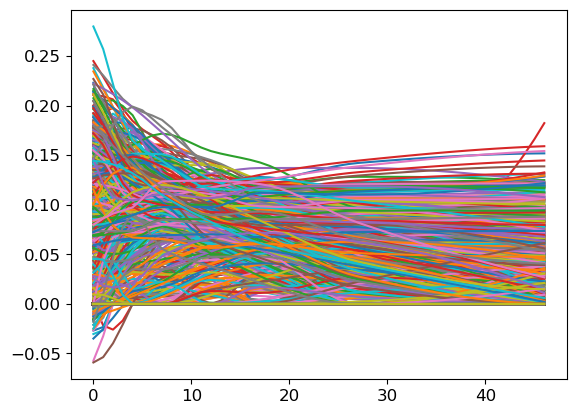

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

mishka_gamma = np.empty_like(mishka_gamma2)
ntor_all = np.arange(3, 50, 1)
gamma_fit = np.empty((mishka_gamma2.shape[0], ntor_all.shape[0]))

for _i, ntor_list in enumerate(mishka_ntor[:1000]):
    print(_i, ntor_list)
    idx = np.argsort(ntor_list)
    print(_i, ntor_list[idx])
    print(mishka_gamma2[_i][idx])
    print(mishka_iterations[_i][idx])

    mishka_ntor[_i]=ntor_list[idx]
    mishka_gamma2[_i]=mishka_gamma2[_i][idx]
    mishka_iterations[_i]=mishka_iterations[_i][idx]
    mishka_gamma[_i] = np.maximum(0.0, mishka_gamma2[_i])**(0.5)
    # Build mask of points to EXCLUDE
    exclude, new_guesses = find_suspicious_points(
        mishka_ntor[_i], mishka_gamma[_i], mishka_iterations[_i])

    # Points used for interpolation
    ntor_fit = mishka_ntor[_i][~exclude]
    gamma_fit_pts = mishka_gamma[_i][~exclude]

    # Need at least 2 points for interpolation
    # if len(ntor_fit) < 2:
    #     print("EXCLUDING", h_dir)
    #     continue

    # Build interpolator (monotone shape preserving)
    interp = PchipInterpolator(ntor_fit, gamma_fit_pts)       
    gamma_fit[_i] = interp(ntor_all)
    plt.plot(gamma_fit[_i])
    

In [18]:
np.sum(gamma_fit[:10])

24.680867374997337

In [1]:
import os
import sys
import json
import logging
from datetime import datetime
import numpy as np
import torch
# from torch import nn
from torch import optim
from torch.utils.data import DataLoader

from karhu.gntor import GammaNtorPredictor, setup_dataset
from karhu.gntor import train_model, test_model, split_dataset
from karhu.training import plot_losses, plot_pred_vs_true, get_regression_scores


# New setup
model_config = {
    "conv_input_sizes": (64, 64, 64, 128),
    "scalar_inputs": 2,
    "scalar_outputs": 47,
    "conv_kernel_sizes": (7, 5, 3),
    "out_channels": 16,
    "pool_kernel_size": 2,
    "fc_hidden_dims": (128, 128),
    "conv_dropout": 0.1,
    "fc_dropout": 0.2,
}
model = GammaNtorPredictor(model_config)
epochs = 10
optimizer = optim.Adam(model.parameters(), lr=1e-3)

dataset, data_config = setup_dataset(dir_path="/scratch/project_2009007/ambrunc/dev_karhu/karhu/db/jet_1H/interpolated64.h5")
config = data_config | model_config
# save_config(SAVE_DIR, config)

# Ratios for splitting data set
test_ratio = 0.10
train_ratio = 0.70
val_ratio = 0.20
train_data, val_data, test_data = split_dataset(
    dataset, train_ratio, val_ratio, test_ratio, base_seed=42)


/scratch/project_2009007/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [5]:
train_loader = DataLoader(train_data, batch_size=1000, shuffle=True)
val_loader = DataLoader(val_data, batch_size=100, shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)


tensor([[0.3955, 0.4028, 0.4105,  ..., 0.2665, 0.2721, 0.2777],
        [0.3857, 0.3933, 0.4010,  ..., 0.2102, 0.2152, 0.2203],
        [0.2391, 0.2437, 0.2485,  ..., 0.4544, 0.4580, 0.4665],
        ...,
        [0.6524, 0.6723, 0.6888,  ..., 0.4054, 0.4145, 0.4240],
        [0.1964, 0.2008, 0.2052,  ..., 0.4940, 0.5101, 0.0775],
        [0.2287, 0.2341, 0.2394,  ..., 0.5342, 0.5454, 0.5560]])

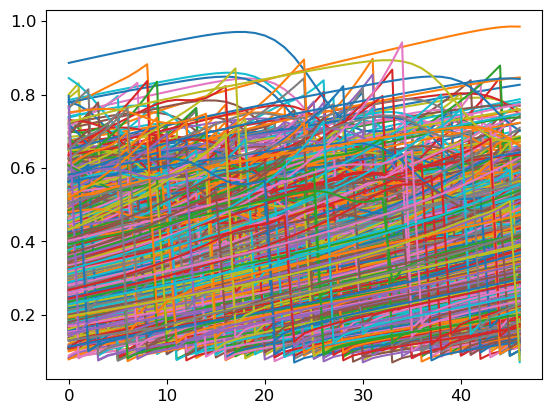

In [6]:
import matplotlib.pyplot as plt
device = 'cpu'
for data in train_loader:
    # Move inputs and labels to the device
    (input_p, input_qs, input_rbphi, input_shape, b_mag, r_mag, labels) = (
        model.get_input_from_batch_data(data, device)
    )
    
    plt.plot(labels.T)
    break

labels

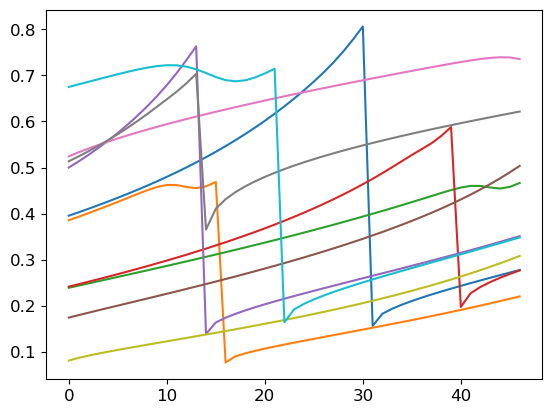

In [8]:
labels.shape

for i in range(10):
    plt.plot(labels[i, :])

In [ ]:

train_losses, val_losses = [], []

loss_dict_epoch = {}
for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for data in train_loader:
        # Move inputs and labels to the device
        (input_p, input_qs, input_rbphi, input_shape, b_mag, r_mag, labels) = (
            model.get_input_from_batch_data(data, device)
        )
        optimizer.zero_grad()
        outputs = model(input_p, input_qs, input_rbphi, input_shape, b_mag, r_mag)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    # mlflow.log_metric("train_loss", train_loss, step=epoch)
    loss_dict_epoch[str(epoch)] = running_loss

    # Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            # Move inputs and labels to the device
            (input_p, input_qs, input_rbphi, input_shape, b_mag, r_mag, labels) = (
                model.get_input_from_batch_data(data, device))
            optimizer.zero_grad()
            outputs =  model(input_p, input_qs, input_rbphi, input_shape, b_mag, r_mag)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    # mlflow.log_metric("val_loss", val_loss, step=epoch)
    logger.info(
        f"Epoch {epoch+1}/{epochs} - "
        + f"Train loss: {train_loss:.6f}, "
        + f"Validation loss: {val_loss:.6f}, "
        + f"Seconds: {time.time()-start_time_epoch:.2f}"
    )

    if early_stopping:   # and epoch > 200:
        early_stopper(val_loss, model, epoch=epoch)
        if early_stopper.early_stop:
            print("Early stopping")
            break

# Load the best model
if early_stopping:
    early_stopper.load_best_model(model)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import (
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def get_regression_scores(y_true, y_pred):
    """
    Calculate prediction scores: MSE, MAE, MAPE, and R2.
    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.
    Returns:
        mse (float): Mean Squared Error.
        mae (float): Mean Absolute Error.
        mape (float): Mean Absolute Percentage Error.
        r2 (float): R-squared score.
    """
    if y_pred.shape != y_true.shape:
        print(f"SHAPE ISSUE: y_true {y_true.shape}, y_pred {y_pred.shape}")

    y_residuals = y_true - y_pred
    mse = np.mean(y_residuals**2)
    mae = np.mean(np.abs(y_residuals))
    # mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    mape = 0.0
    r2 = r2_score(y_true, y_pred)
    return {"mse": mse, "mae": mae, "mape": mape, "r2": r2}

import numpy as np
import matplotlib.pyplot as plt

def plot_pred_vs_true(y_test, y_pred, y_pred_std=None, filename=None, gridsize=60):
    """
    Plot predicted vs true values using a density (hexbin) plot.

    This visualization is designed for large datasets where scatter plots
    suffer from overplotting. The density of samples is shown using a 2D
    hexagonal histogram with logarithmic color scaling.

    Args:
        y_test (array-like): True target values.
        y_pred (array-like): Predicted mean values.
        y_pred_std (array-like, cvael): Predictive standard deviation.
            If provided, the mean uncertainty is shown in the title and a
            faint scatter of predictions is added on top of the density.
        filename (str, cvael): Path to save the figure.
        gridsize (int, cvael): Number of hexagons in the x-direction.
            Higher values give finer resolution.

    Returns:
        matplotlib.figure.Figure: The created figure.
    """
    y_test = np.asarray(y_test).squeeze()
    y_pred = np.asarray(y_pred).squeeze()

    if y_pred_std is not None:
        y_pred_std = np.asarray(y_pred_std).squeeze()

    metrics = get_regression_scores(y_true=y_test, y_pred=y_pred)
    mae, r2 = metrics["mae"], metrics["r2"]

    fig, ax = plt.subplots(figsize=(8, 5))

    # --- Density plot ---
    hb = ax.hexbin(
        y_test,
        y_pred,
        gridsize=gridsize,
        bins="log",          # log density is crucial
        cmap="viridis",
        mincnt=1
    )

    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label("log10(N samples per bin)")

    # cvael faint scatter to show spread / outliers
    if y_pred_std is not None:
        ax.scatter(y_test, y_pred, s=5, alpha=0.05, color="black")
        mean_std = np.mean(y_pred_std)
        title = f"R² = {r2:.5f}   MAE = {mae:.5f}   ⟨σ⟩ = {mean_std:.5f}"
    else:
        title = f"R² = {r2:.5f}   MAE = {mae:.5f}"

    # Ideal line
    min_val = min(np.min(y_test), np.min(y_pred))
    max_val = max(np.max(y_test), np.max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Ideal")

    # Formatting
    ax.set_title(title)
    ax.set_xlabel(r"True $\gamma_{\mathrm{max}}$")
    ax.set_ylabel(r"Predicted $\gamma_{\mathrm{max}}$")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if filename:
        fig.savefig(filename, dpi=300)
        print(f"Figure saved: {filename}")

    return fig

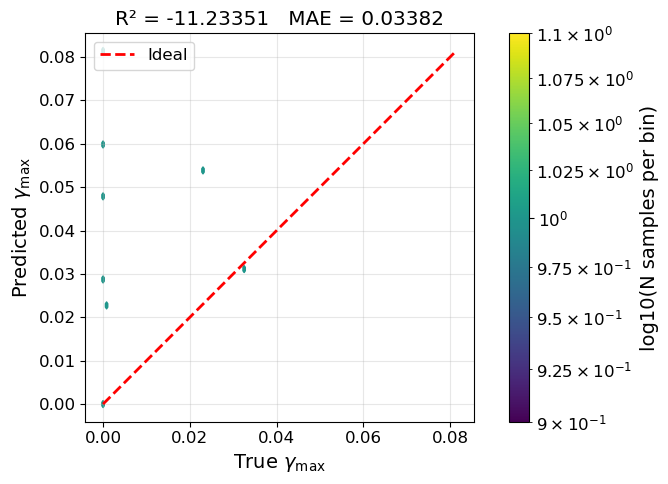

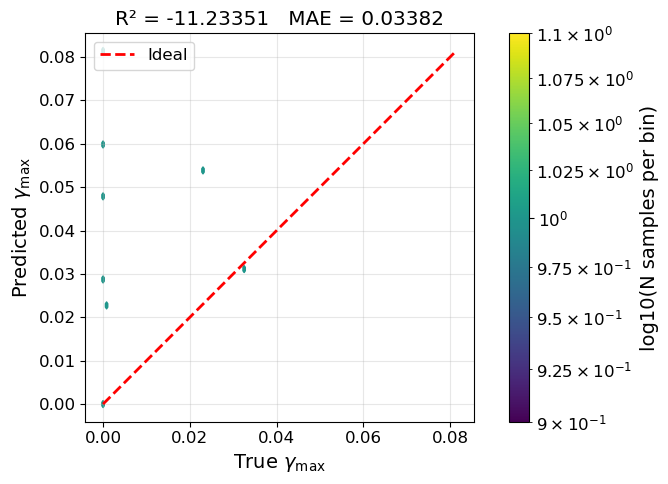

In [16]:
plot_pred_vs_true(y_true, y_pred[[0,2,3,10,20,25,30,46]], y_pred_std=None, filename=None, gridsize=60)